# Лабораторна робота №2 — Класифікація Fashion MNIST за допомогою CNN (Keras)

**Студентка:** Olena Mykhailovska  
**Група:** CS-31  
**STUDENT_NO:** 12

1. Встановлення та імпорт бібліотек

In [1]:
!pip install tensorflow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. Завантаження набору даних

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Розмір навчальної вибірки:", x_train.shape)
print("Розмір тестової вибірки:", x_test.shape)

Розмір навчальної вибірки: (60000, 28, 28)
Розмір тестової вибірки: (10000, 28, 28)


# ЗАВДАННЯ 1
Відображення зображення

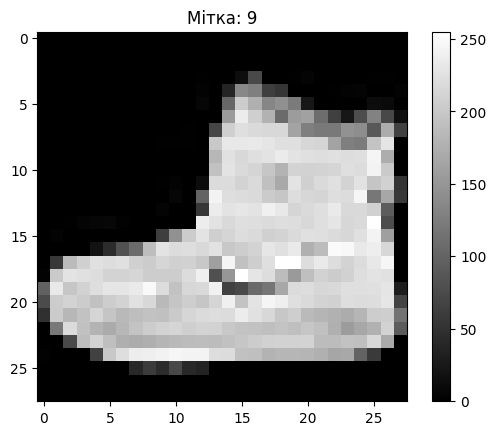

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title("Мітка: " + str(y_train[0]))
plt.colorbar()
plt.show()

# ЗАВДАННЯ 2
Нормалізація даних

Значення пікселів знаходяться в діапазоні 0–255.
Ділимо на 255 для приведення до [0,1].

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# ЗАВДАННЯ 3
Додавання каналу (4-й вимір)

CNN очікує формат:
(кількість, висота, ширина, канали)

In [5]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Нова форма x_train:", x_train.shape)

Нова форма x_train: (60000, 28, 28, 1)


# ЗАВДАННЯ 4
One-Hot Encoding для міток

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Форма y_train після кодування:", y_train_cat.shape)

Форма y_train після кодування: (60000, 10)


Створення CNN моделі

In [7]:
model = Sequential()

# Згортковий шар
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))

# Пулінг
model.add(MaxPooling2D(pool_size=(2,2)))

# Перетворення у вектор
model.add(Flatten())

# Повнозв'язний шар
model.add(Dense(128, activation='relu'))

# Вихідний шар
model.add(Dense(10, activation='softmax'))

model.summary()

c:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Компіляція моделі

In [8]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

# ЗАВДАННЯ 5
Навчання моделі

In [9]:
history = model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8054 - loss: 0.5472 - val_accuracy: 0.8619 - val_loss: 0.3843
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8781 - loss: 0.3431 - val_accuracy: 0.8805 - val_loss: 0.3341
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8957 - loss: 0.2924 - val_accuracy: 0.8966 - val_loss: 0.2921
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9064 - loss: 0.2597 - val_accuracy: 0.9028 - val_loss: 0.2720
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9168 - loss: 0.2328 - val_accuracy: 0.9021 - val_loss: 0.2701
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9231 - loss: 0.2111 - val_accuracy: 0.9064 - val_loss: 0.2576
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9285 - loss: 0.1951 - val_accuracy: 0.9096 - val_loss: 0.2467
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9344 - loss: 0.1782 - val_accu

# ЗАВДАННЯ 6
Оцінка моделі

Accuracy на тестових даних

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9055 - loss: 0.2693
Test accuracy: 0.9054999947547913


Precision, Recall, F1-score

In [11]:
# Отримуємо передбачення
y_pred = model.predict(x_test)

# Перетворюємо у звичайні мітки
y_pred_classes = np.argmax(y_pred, axis=1)

# Виводимо звіт
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.89      0.82      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.84      0.86      0.85      1000
           3       0.90      0.93      0.91      1000
           4       0.88      0.81      0.84      1000
           5       0.98      0.98      0.98      1000
           6       0.73      0.80      0.76      1000
           7       0.97      0.91      0.94      1000
           8       0.98      0.98      0.98      1000
           9       0.92      0.98      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



# Висновок

У ході виконання практичної роботи було побудовано згорткову нейронну мережу (CNN) для класифікації зображень набору даних Fashion MNIST.

## Підготовка даних

- Навчальна вибірка: **60000 зображень (28×28)**
- Тестова вибірка: **10000 зображень (28×28)**
- Дані були нормалізовані до діапазону [0,1]
- До масивів додано 4-й вимір (канал)
- Мітки перетворено у формат **one-hot encoding (60000, 10)**

## Архітектура моделі

Модель складається з:
- Conv2D (32 фільтри, 3×3)
- MaxPooling2D (2×2)
- Flatten
- Dense (128, ReLU)
- Dense (10, Softmax)

Загальна кількість параметрів: **693 962**, усі параметри є навчальними.

## Результати навчання

Протягом 10 епох точність на навчальній вибірці зросла з **80.5% до 94.5%**,  
а валідаційна точність стабілізувалася на рівні **≈91%**.

Фінальна точність на тестовій вибірці:

> **Test accuracy = 0.9055 (≈ 90.5%)**

## Метрики якості

Середні значення:
- **Accuracy:** 0.91
- **Precision (macro avg):** 0.91
- **Recall (macro avg):** 0.91
- **F1-score (macro avg):** 0.91

Найкраще модель класифікує:
- Trouser (F1 ≈ 0.99)
- Sandal (F1 ≈ 0.98)
- Bag (F1 ≈ 0.98)

Найскладніші класи:
- Shirt (F1 ≈ 0.76)
- Coat (F1 ≈ 0.84)

Це пояснюється схожістю візуальних ознак між типами верхнього одягу.

## Загальний висновок

Згорткова нейронна мережа показала високу ефективність при класифікації зображень Fashion MNIST.  
Досягнута точність понад 90% підтверджує, що навіть проста CNN-архітектура здатна добре розпізнавати об'єкти на зображеннях невеликого розміру.

Модель демонструє стабільне навчання без значного перенавчання, що підтверджується близькими значеннями training та validation accuracy.